Binary criticality classifier using fully connected neural network
---

In [ ]:
import numpy as np
import glob
import os

def load_ising_data(folder_path):
    x_data = []
    y_data = []
    file_list = glob.glob(os.path.join(folder_path, "*.npz"))
    
    for file_path in file_list:
        with np.load(file_path) as data:
            # Instead of ['arr_0'], use data.files[0] to get the first array
            first_key = data.files[0] 
            matrix = data[first_key]
            x_data.append(matrix)
            
        filename = os.path.basename(file_path)
        if "above" in filename:
            y_data.append(1)
        elif "below" in filename:
            y_data.append(0)
            
    return np.array(x_data), np.array(y_data)

# Usage
x_raw, y_train = load_ising_data(r'C:Users\raboc\Desktop\Ising-BME-main\data')

#3. Final Prep for the Dense Network
#Flatten the (Samples, 10, 10) into (Samples, 100)
x_train_flat = x_raw.reshape(x_raw.shape[0], -1)

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
# 1. Configuration (Based on our agreed parameters)
N = 200  # Snippet size (can be changed to 100 later)
INPUT_SHAPE = N * N
BATCH_SIZE = 32
EPOCHS = 20

def build_ising_model(input_dim):
    model = models.Sequential([
        # Flatten the n x n grid into a 1D vector
        layers.Input(shape=(input_dim,)),
        
        # Hidden Layer 1
        layers.Dense(64, activation='relu'),
        
        # Hidden Layer 2
        layers.Dense(32, activation='relu'),
        
        # Output Layer: Sigmoid squashes output to range [0, 1]
        layers.Dense(1, activation='sigmoid')
    ])

    # Using Binary Cross-Entropy as agreed
    # 'adam' is a reliable optimizer that adjusts learning rates automatically
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# 2. Data Loading Placeholder
# Your friend should provide x_train as (samples, N, N) and y_train as (samples,)
# For now, let's assume they are flattened or we flatten them here:

# Example: Generate dummy data for testing the skeleton
# x_train = np.random.choice([-1, 1], size=(1000, N, N))
# y_train = np.random.randint(0, 2, size=(1000,))

# Flattening the grid for the Dense network
# x_train_flat = x_train.reshape(-1, INPUT_SHAPE)

# 3. Initialize and Train
model = build_ising_model(INPUT_SHAPE)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.4  # Uses 20% of data to check for overfitting
)

# 4. Save the model
# model.save('ising_classifier_v1.h5')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,562,177 (9.77 MB)

 Trainable params: 2,562,177 (9.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5944 - loss: 4.0305 - val_accuracy: 0.0000e+00 - val_loss: 1.9872
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7444 - loss: 0.8307 - val_accuracy: 0.6167 - val_loss: 0.6916
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8944 - loss: 0.3944 - val_accuracy: 1.0000 - val_loss: 8.7991e-05
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8444 - loss: 0.4171 - val_accuracy: 1.0000 - val_loss: 0.1957
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9444 - loss: 0.1460 - val_accuracy: 0.9917 - val_loss: 0.2862
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9389 - loss: 0.1144 - val_accuracy: 1.0000 - val_loss: 4.7124e-04
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9556 - loss: 0.0712 - val_accuracy: 0.5167 - val_loss: 0.7699
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 1.0000 - val_l

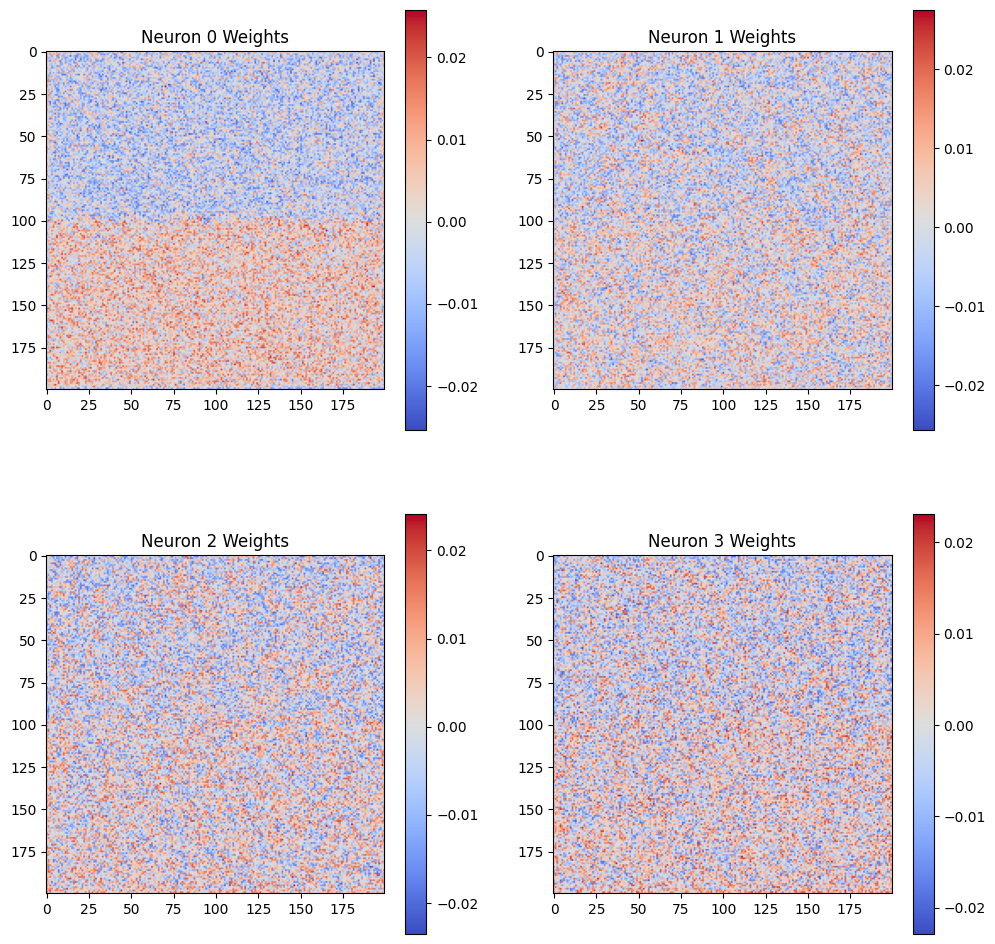

In [21]:
import matplotlib.pyplot as plt

# model.weights[0] has shape (40000, 64)
weights = model.get_weights()[0] 

# Let's plot the first 4 neurons as 200x200 images
plt.figure(figsize=(12, 12))
for i in range(4):
    plt.subplot(2, 2, i+1)
    # Reshape the 40,000 weights for one neuron back to 200x200
    neuron_weights = weights[:, i].reshape(200, 200)
    plt.imshow(neuron_weights, cmap='coolwarm')
    plt.title(f'Neuron {i} Weights')
    plt.colorbar()
plt.show()

Results are encouraging as accuracy reached 1 even with many of the samples used having been close to the literature critical temperature.
---
Note: Gemini was used heavily in the designing and writing of this investigation, all use can be read here: https://gemini.google.com/share/8096db4425ea